In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

In [3]:
rf = joblib.load("../models/random_forest.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [4]:
df = pd.read_csv("../data/processed/cleaned_pcos.csv")

print(df.shape)

(541, 42)


In [5]:
X = df.drop("PCOS (Y/N)", axis=1)

print(X.shape)

(541, 41)


In [6]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
37,Follicle No. (R),0.183278
36,Follicle No. (L),0.125951
29,Skin darkening (Y/N),0.056597
27,Weight gain(Y/N),0.053453
28,hair growth(Y/N),0.050487
22,AMH(ng/mL),0.034437
9,Cycle length(days),0.026985
8,Cycle(R/I),0.026114
3,BMI,0.022917
32,Fast food (Y/N),0.021881


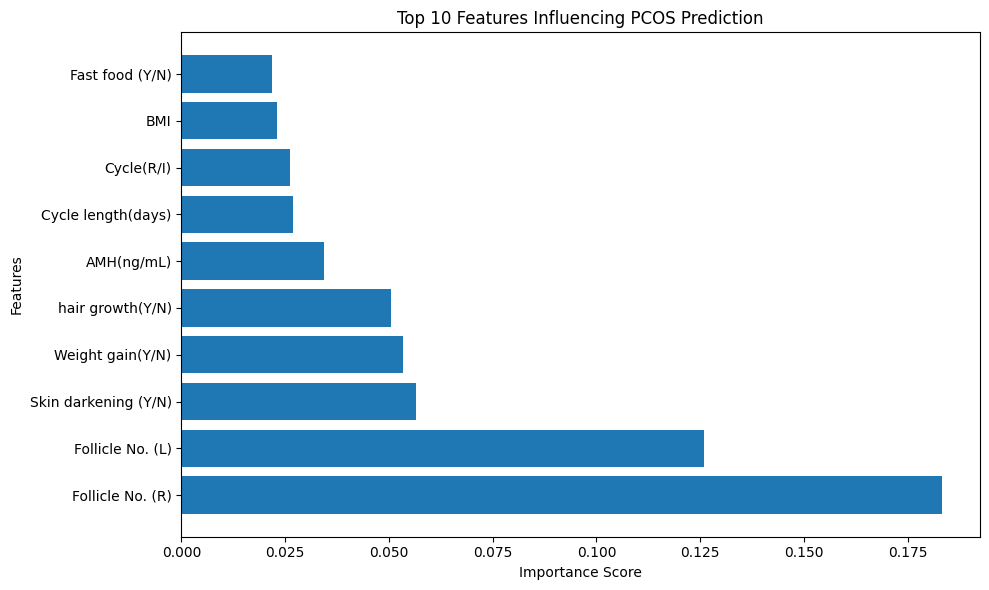

In [7]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing PCOS Prediction")

plt.tight_layout()

plt.show()

In [8]:
top5 = importance_df.head(5)

print(top5)

                 Feature  Importance
37      Follicle No. (R)    0.183278
36      Follicle No. (L)    0.125951
29  Skin darkening (Y/N)    0.056597
27      Weight gain(Y/N)    0.053453
28      hair growth(Y/N)    0.050487


In [10]:
top5["Percentage"] = (
    top5["Importance"] /
    top5["Importance"].sum()
) * 100

top5

C:\Users\lenovo\AppData\Local\Temp\ipykernel_18264\533358887.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5["Percentage"] = (


,Feature,Importance,Percentage
37,Follicle No. (R),0.183278,39.014771
36,Follicle No. (L),0.125951,26.811373
29,Skin darkening (Y/N),0.056597,12.048002
27,Weight gain(Y/N),0.053453,11.378650
28,hair growth(Y/N),0.050487,10.747205


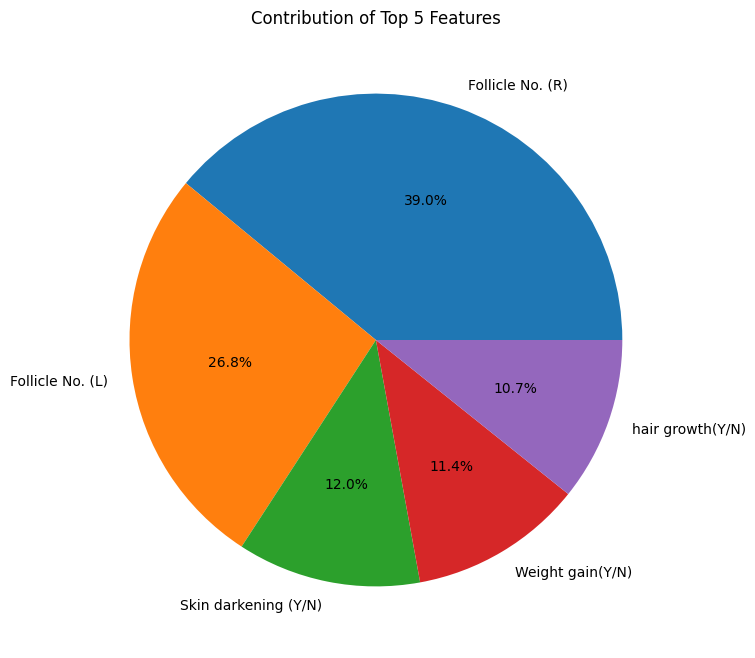

In [11]:
plt.figure(figsize=(8,8))

plt.pie(
    top5["Percentage"],
    labels=top5["Feature"],
    autopct="%1.1f%%"
)

plt.title("Contribution of Top 5 Features")

plt.show()

In [12]:
print("Most Important Features:")

for i, feature in enumerate(
    importance_df["Feature"].head(10),
    start=1
):
    print(f"{i}. {feature}")

Most Important Features:
1. Follicle No. (R)
2. Follicle No. (L)
3. Skin darkening (Y/N)
4. Weight gain(Y/N)
5. hair growth(Y/N)
6. AMH(ng/mL)
7. Cycle length(days)
8. Cycle(R/I)
9. BMI
10. Fast food (Y/N)


# Conclusion

The Random Forest model identifies the following factors as the strongest indicators of PCOS:

1. Follicle No. (Right Ovary)
2. Follicle No. (Left Ovary)
3. Skin Darkening
4. Weight Gain
5. Hair Growth
6. AMH Levels

These findings align with known clinical indicators of PCOS and improve trust in the model's predictions.